In [ ]:
!pip install -U mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 10.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
#import geopandas as gpd  # writing note
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from scipy.stats import kurtosis


import mapclassify as mc


In [ ]:
data_dir = './drive/MyDrive/GE5230-2510/data_base/'
os.listdir(data_dir)

['hdb_data_2023.csv.xz', 'hdb_data_2013.csv.xz']

In [ ]:
fname = 'hdb_data_2023.csv.xz'
fp = os.path.join(data_dir, fname)
print(fp)
df = pd.read_csv(fp, index_col=0)
df.head()

./drive/MyDrive/GE5230-2510/data_base/hdb_data_2023.csv.xz


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,resale_year,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,2023,1,44,406 ANG MO KIO AVE 10,1.362005,103.853880,30288.234663,38229.067463,560406,POINT (30288.2346631354 38229.0674628187)
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,2023,1,46,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235)
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,2023,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912)
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,2023,1,37,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959)


<Axes: xlabel='storey_range', ylabel='resale_price'>

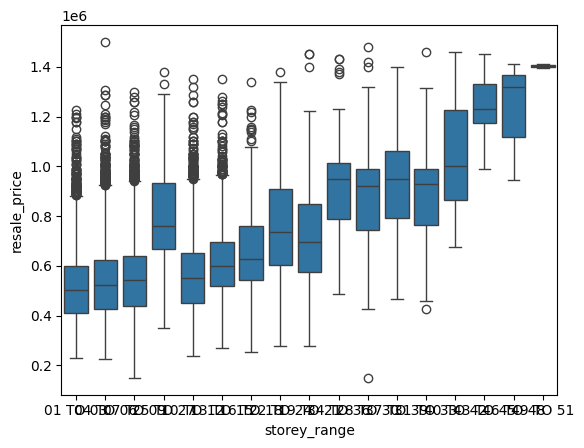

In [ ]:
sns.boxplot(x='storey_range', y='resale_price', data=df)

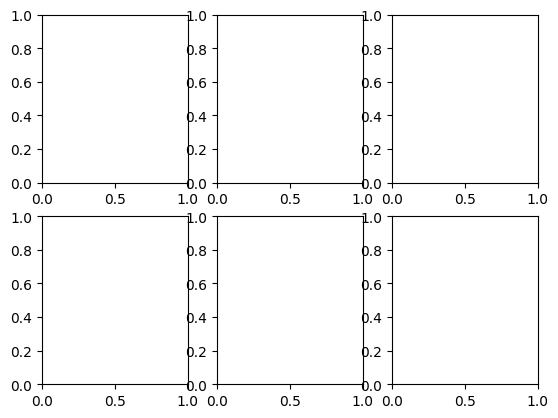

In [ ]:
fig, ax = plt.subplots(2, 3)


In [ ]:
df['storey_range'].unique()

array(['01 TO 03', '04 TO 06', '07 TO 09', '25 TO 27', '10 TO 12',
       '13 TO 15', '16 TO 18', '22 TO 24', '19 TO 21', '34 TO 36',
       '28 TO 30', '37 TO 39', '31 TO 33', '40 TO 42', '43 TO 45',
       '46 TO 48', '49 TO 51'], dtype=object)

[Text(0, 0, '01 TO 03'), Text(1, 0, '04 TO 06'), Text(2, 0, '07 TO 09'), Text(3, 0, '10 TO 12'), Text(4, 0, '13 TO 15'), Text(5, 0, '16 TO 18'), Text(6, 0, '19 TO 21'), Text(7, 0, '22 TO 24'), Text(8, 0, '25 TO 27'), Text(9, 0, '28 TO 30'), Text(10, 0, '31 TO 33'), Text(11, 0, '34 TO 36'), Text(12, 0, '37 TO 39'), Text(13, 0, '40 TO 42'), Text(14, 0, '43 TO 45'), Text(15, 0, '46 TO 48'), Text(16, 0, '49 TO 51')]


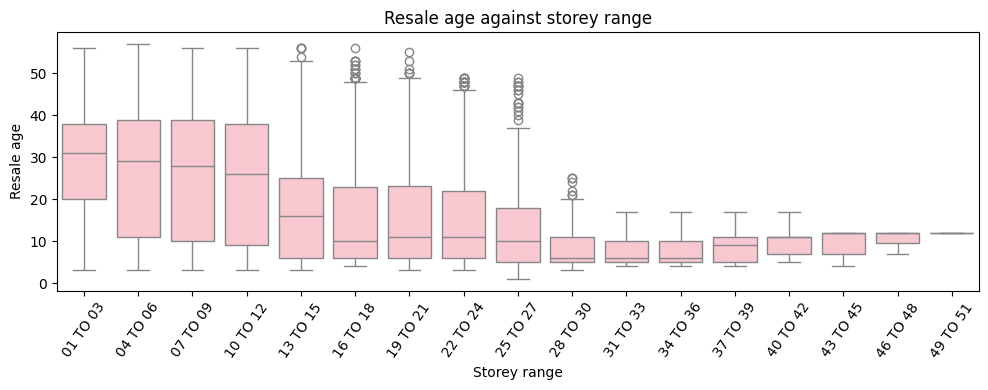

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(x='storey_range', y='resale_age',
            color='pink', order=sorted(df['storey_range'].unique()),
            data=df, ax=ax)

xs = ax.get_xticklabels()
print(xs)
xs = [x.get_text() for x in xs]
ax.set_xticks(xs)
ax.set_xticklabels(xs, rotation=55)
ax.set_title('Resale age against storey range')
ax.set_xlabel('Storey range')
ax.set_ylabel('Resale age')
#

plt.tight_layout()

In [ ]:
clrs = sns.color_palette('colorblind')
clrs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

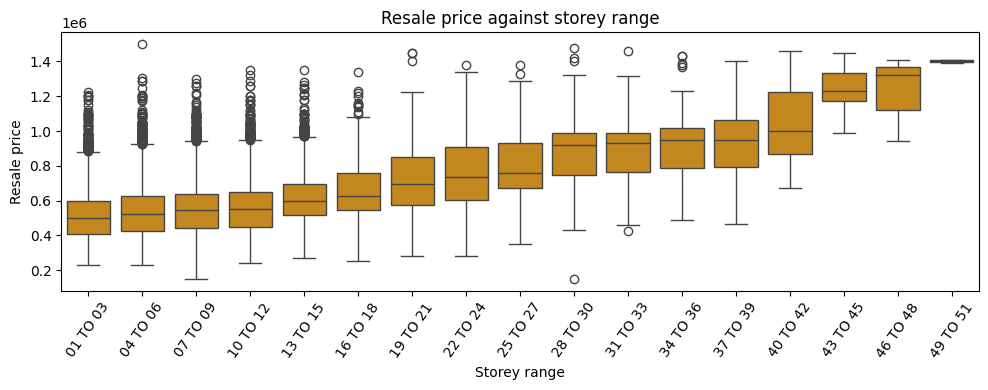

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(x='storey_range', y='resale_price',
            color=clrs[1], order=sorted(df['storey_range'].unique()),
            data=df, ax=ax)
xs = ax.get_xticklabels()
xs = [x.get_text() for x in xs]
ax.set_xticks(xs)
ax.set_xticklabels(xs, rotation=55)
ax.set_title('Resale price against storey range')
ax.set_xlabel('Storey range')
ax.set_ylabel('Resale price')
#print(xs)
plt.tight_layout()

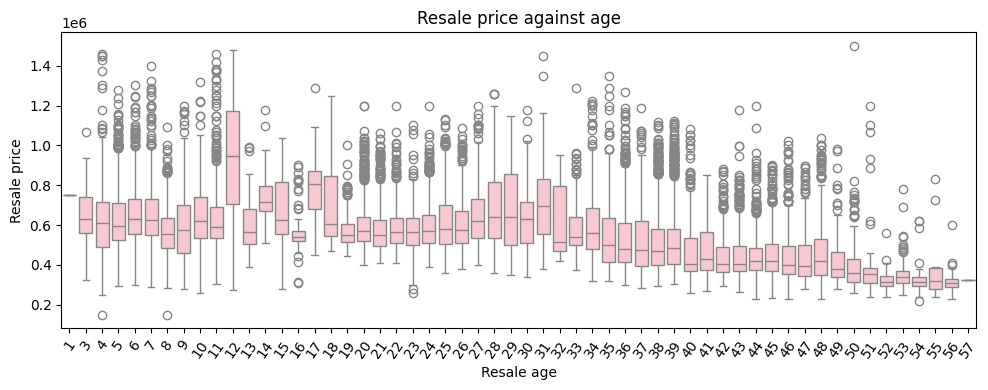

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(x='resale_age', y='resale_price',
            color='pink', order=sorted(df['resale_age'].unique()),
            data=df, ax=ax)
xs = ax.get_xticklabels()
xs = [x.get_text() for x in xs]
ax.set_xticks(xs)
ax.set_xticklabels(xs, rotation=55)
ax.set_title('Resale price against age')
ax.set_xlabel('Resale age')
ax.set_ylabel('Resale price')
#print(xs)
plt.tight_layout()

<Axes: xlabel='resale_age', ylabel='Count'>

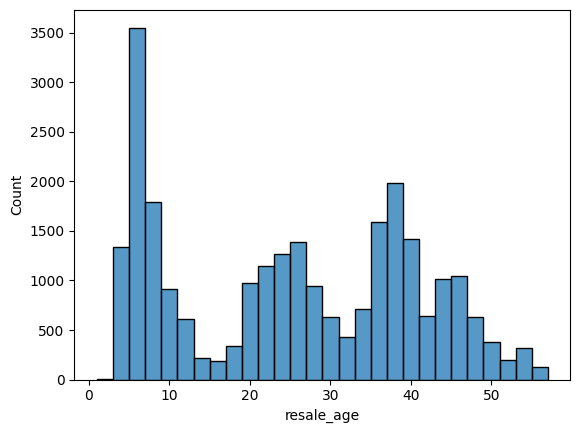

In [ ]:
sns.histplot(x='resale_age', data=df)

<Axes: xlabel='resale_age', ylabel='Density'>

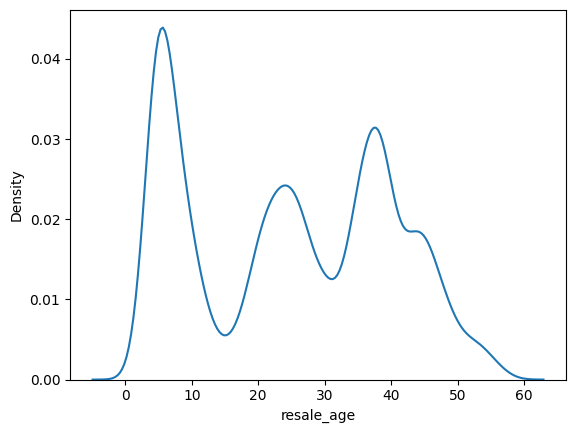

In [ ]:
sns.kdeplot(x='resale_age', data=df)

<Axes: xlabel='resale_age', ylabel='Count'>

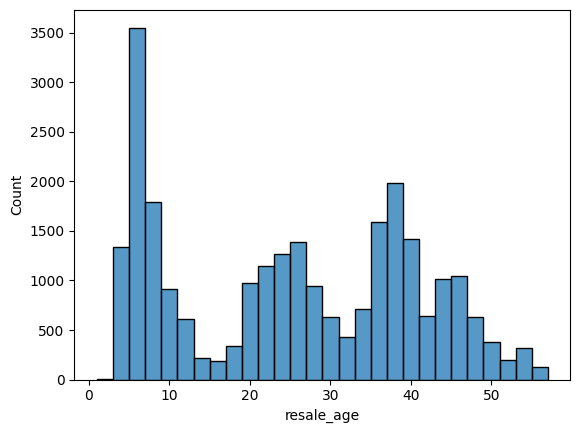

In [ ]:
sns.histplot(x=df['resale_age'])

<Axes: xlabel='resale_age', ylabel='Count'>

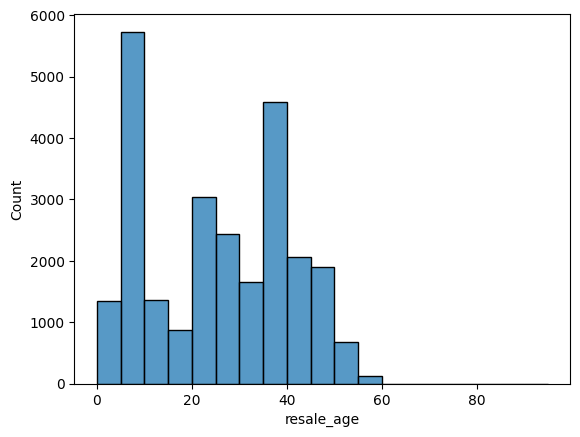

In [ ]:
sns.histplot(x='resale_age', data=df, bins=[x*5 for x in range(20)])

In [ ]:
list(range(20))  # from zero to the integer before the number here (12)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [ ]:
list(range(5, 12))  # from the first number (innclusive, 5) to the integer before the last number here (12)

[5, 6, 7, 8, 9, 10, 11]

In [ ]:
[x*5 for x in range(13)]  # list comprehension in python

[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]

In [ ]:
a_list = [] # list()
for x in range(13):
    a_list.append(x*5)
print(a_list)

[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]


In [ ]:
np.histogram(df['resale_age'])

(array([4889, 3325,  546, 2922, 2968, 1768, 4984, 2342, 1464,  552]),
 array([ 1. ,  6.6, 12.2, 17.8, 23.4, 29. , 34.6, 40.2, 45.8, 51.4, 57. ]))

In [ ]:
np.histogram(df['resale_age'], bins=[x*5 for x in range(20)])

(array([1339, 5732, 1357,  865, 3035, 2443, 1647, 4591, 2054, 1901,  669,
         127,    0,    0,    0,    0,    0,    0,    0]),
 array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80,
        85, 90, 95]))

<Axes: xlabel='resale_price', ylabel='Count'>

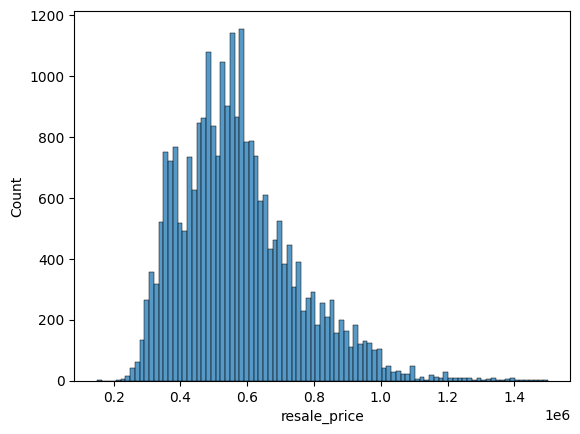

In [ ]:
sns.histplot(x='resale_price', data=df, )

0.0 1.0


<Axes: ylabel='Count'>

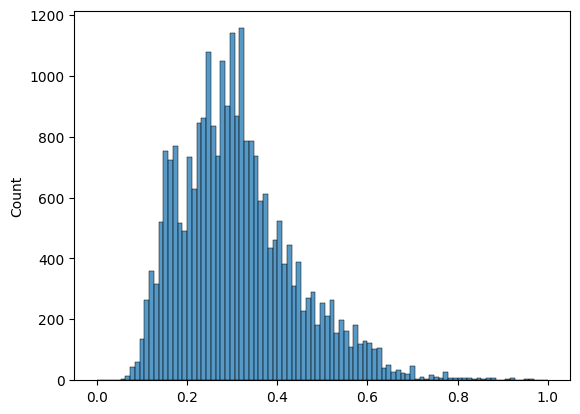

In [ ]:
vs = df['resale_price'].to_list()
vmin = min(vs)
vmax = max(vs)

min_max_vs = [ (v-vmin) / (vmax - vmin) for v in vs ]
print(min(min_max_vs), max(min_max_vs))
sns.histplot(min_max_vs)

1.0 100.0


<Axes: ylabel='Count'>

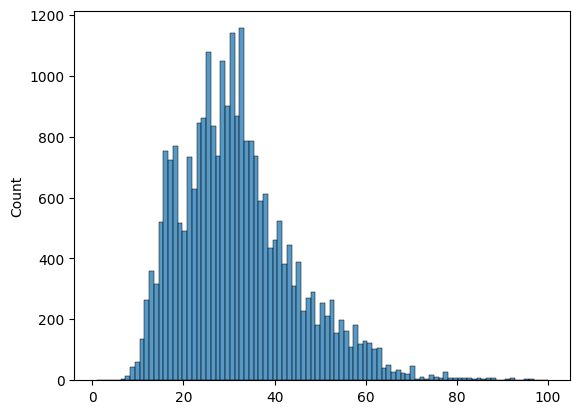

In [ ]:

min_max_vs2 = [ (v-vmin) / (vmax - vmin) * (100 - 1) + 1 for v in vs ]
print(min(min_max_vs2), max(min_max_vs2))
sns.histplot(min_max_vs2)

-2.426712683085751 5.340097262303216


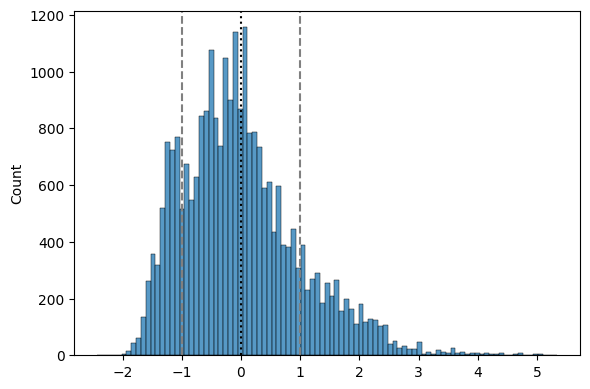

In [ ]:
mu = np.mean(vs)
sig = np.std(vs)
std_vs = [ (v - mu) / sig for v in vs ]

print(min(std_vs), max(std_vs))
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(std_vs, ax=ax)
ax.axvline(x=np.mean(std_vs), ls=':', c='k')
ax.axvline(x=np.mean(std_vs) + np.std(std_vs), ls='--', c='grey')
ax.axvline(x=np.mean(std_vs) - np.std(std_vs), ls='--', c='grey')
plt.tight_layout()

<Axes: ylabel='Count'>

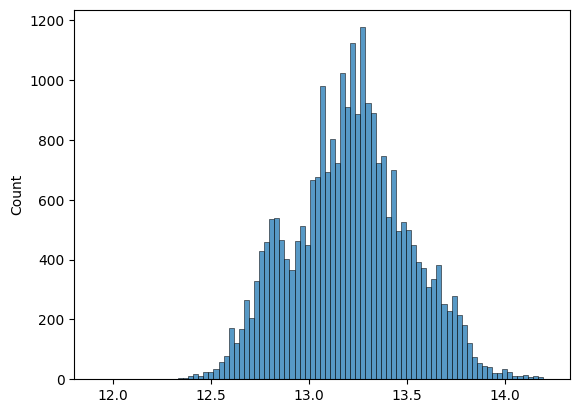

In [ ]:
vs_log = np.log(vs)
sns.histplot(vs_log)

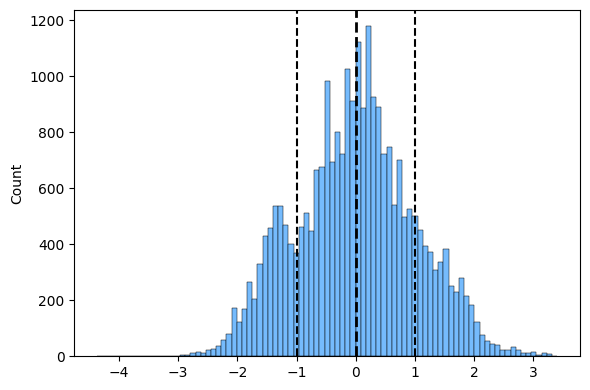

In [ ]:
mu = np.mean(vs_log)
sig = np.std(vs_log)
std_log_vs = [ (v - mu) / sig for v in vs_log ]

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(std_log_vs, ax=ax, fc='xkcd:sky blue')
ax.axvline(x=np.mean(std_log_vs), ls='--', c='k', lw=2)
ax.axvline(x=np.mean(std_log_vs) + np.std(std_log_vs), ls='--', c='k')
ax.axvline(x=np.mean(std_log_vs) - np.std(std_log_vs), ls='--', c='k')
plt.tight_layout()

In [ ]:

kurtosis_fisher = kurtosis(vs, fisher=True)
kurtosis_pearson = kurtosis(vs, fisher=False)

kurtosis_fisher, kurtosis_pearson

(np.float64(1.1714493440532223), np.float64(4.171449344053222))

In [ ]:

kurtosis_fisher = kurtosis(vs_log, fisher=True)
kurtosis_pearson = kurtosis(vs_log, fisher=False)

kurtosis_fisher, kurtosis_pearson

(np.float64(-0.235457303880386), np.float64(2.764542696119614))

In [ ]:

kurtosis_fisher = kurtosis(std_log_vs, fisher=True)
kurtosis_pearson = kurtosis(std_log_vs, fisher=False)

kurtosis_fisher, kurtosis_pearson

(np.float64(-0.2354573038803882), np.float64(2.764542696119612))

fisher: bool, optional  
If True, Fisher’s definition is used (normal ==> 0.0).  
If False, Pearson’s definition is used (normal ==> 3.0).

In [ ]:
breaks = mc.EqualInterval(vs)
breaks

EqualInterval

        Interval           Count
--------------------------------
[ 150000.00,  420000.00] |  5152
( 420000.00,  690000.00] | 15182
( 690000.00,  960000.00] |  4713
( 960000.00, 1230000.00] |   634
(1230000.00, 1500000.00] |    79

In [ ]:
breaks.yb

array([0, 0, 0, ..., 2, 2, 3])

In [ ]:
breaks.bins

array([ 420000.,  690000.,  960000., 1230000., 1500000.])

In [ ]:
np.histogram(vs, bins=list(breaks.bins))

(array([15233,  4806,   673,    81]),
 array([ 420000.,  690000.,  960000., 1230000., 1500000.]))

In [ ]:
np.histogram(vs, bins=[150000] + [x for x in list(breaks.bins)])

(array([ 4967, 15233,  4806,   673,    81]),
 array([ 150000.,  420000.,  690000.,  960000., 1230000., 1500000.]))

In [ ]:
len(vs)

25760

In [ ]:
sum([4967, 15233,  4806,   673,    81]) ,sum([5152, 15182,  4713,   634,    79])

(25760, 25760)

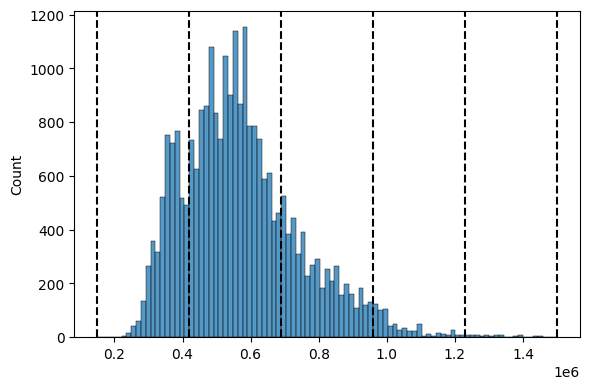

In [ ]:
breaks = mc.EqualInterval(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')

plt.tight_layout()

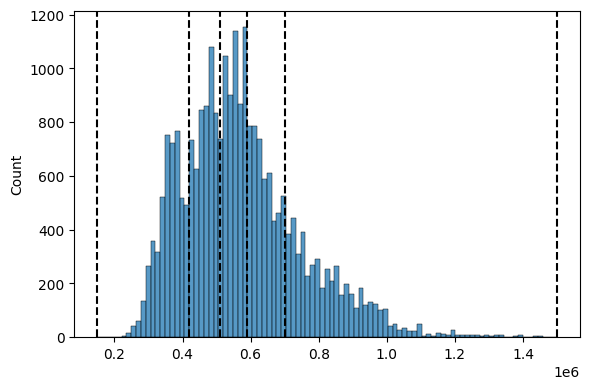

In [ ]:
breaks = mc.Quantiles(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

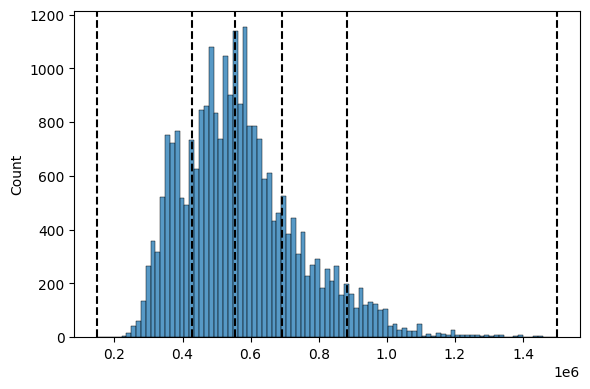

In [ ]:
breaks = mc.NaturalBreaks(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

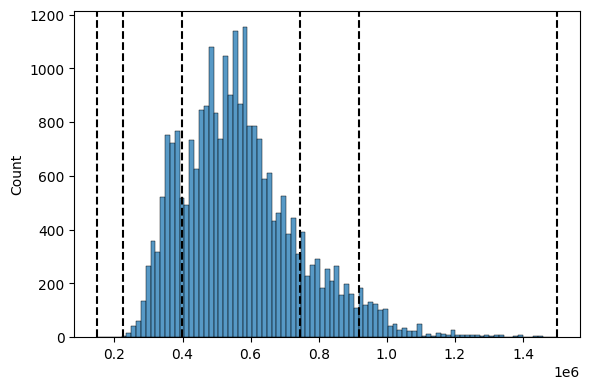

In [ ]:
breaks = mc.StdMean(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

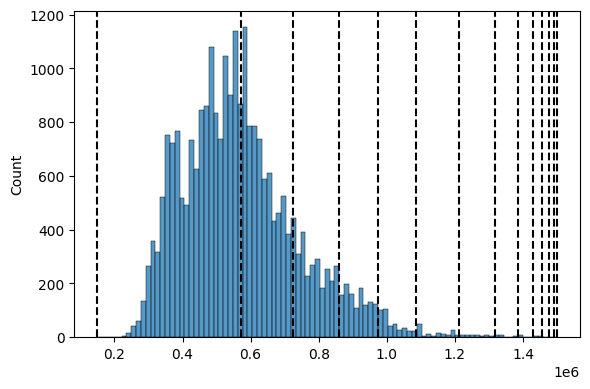

In [ ]:
breaks = mc.HeadTailBreaks(vs)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vs)

ax.axvline(x=min(vs), c='k', ls='--')
for cut in breaks.bins:
    ax.axvline(x=cut, c='k', ls='--')
plt.tight_layout()

In [ ]:
df['htbreaks_yb'] = breaks.yb

In [ ]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,resale_month,resale_age,ADDRESS,LAT,LNG,X,Y,POSTAL,geometry,htbreaks_yb
0,2023-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,267000.0,...,1,44,406 ANG MO KIO AVE 10,1.362005,103.853880,30288.234663,38229.067463,560406,POINT (30288.2346631354 38229.0674628187),0
1,2023-01,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,04 TO 06,49.0,Improved,1977,300000.0,...,1,46,323 ANG MO KIO AVE 3,1.367908,103.847714,29602.047153,38881.891694,560323,POINT (29602.0471531954 38881.8916942235),0
2,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,04 TO 06,44.0,Improved,1978,280000.0,...,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912),0
3,2023-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,282000.0,...,1,45,314 ANG MO KIO AVE 3,1.366227,103.850086,29865.998046,38695.970271,560314,POINT (29865.9980458226 38695.9702712912),0
4,2023-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,289800.0,...,1,37,170 ANG MO KIO AVE 4,1.374001,103.836432,28346.433332,39555.534275,560170,POINT (28346.4333322113 39555.5342750959),0


In [ ]:
for g in df['htbreaks_yb'].unique():
    tmp = df[df['htbreaks_yb']==g]
    print(g, len(tmp))


0 14363
1 6903
2 2688
3 1175
4 401
5 139
6 49
7 21
8 11
12 1
11 1
10 2
9 6


<Axes: xlabel='htbreaks_yb', ylabel='resale_price'>

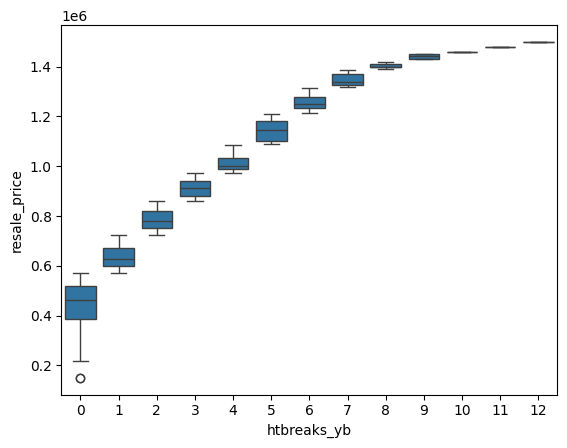

In [ ]:
sns.boxplot(x='htbreaks_yb', y='resale_price', data=df)

<Axes: xlabel='htbreaks_yb', ylabel='resale_age'>

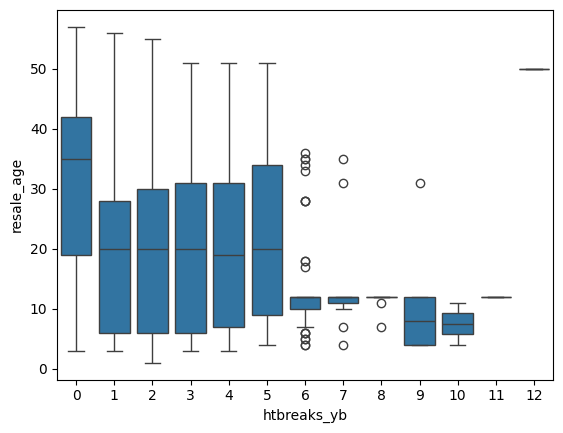

In [ ]:
sns.boxplot(x='htbreaks_yb', y='resale_age', data=df)